In [1]:
# Import all necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif # for calculating the mutual information for feature selection
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier 
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay # for model evaluation
import joblib # for saving and loading machine learning models
import shap # for explainable AI
import lime
from lime.lime_tabular import LimeTabularExplainer
import json

# Avoid warnings that can cause clutter when using XGBoost
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

## Data Cleaning

In [2]:
# Load the dataset into a pandas DataFrame
diabetic_data = pd.read_csv('diabetic_data.csv', header=0, encoding='utf-8')

# View the first five rows of the DataFrame
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Check the dimensions of the dataset
diabetic_data.shape

(101766, 50)

In [4]:
# Get a summary statistics for all numerical columns
diabetic_data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
# Display information (column names, data type, missing values) about the dataset
diabetic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
# Inspecting the dataset I realised that '?' is used as a placeholder for missing values
# Replace those with NaN to get the true state of missing values
diabetic_data.replace("?", np.nan, inplace=True)

In [7]:
"""
For a medical diagnostics dataset specifically curated to predict diabetes
reoccurance, it's quite strange that a key attribute such as weight which
has been scientifically linked to diabetes has so many missing values. This is
a major limitation of this dataset and research in general.
"""
# Check for columns with missing values
diabetic_data.isnull().sum()[
    diabetic_data.isnull().sum() > 0
]

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

In [8]:
"""
Looking at the proportion of missing values we can derive some more insight into
the quality of data collected. 96% of weight data is missing, essentially rendering that
column unusable for modeling purposes. There are imputation techniques to use when
dealing with missing values but I am more comfortable using them when there are only
few missing values. If we use imputation on an attribute with say 50% missing values
then we severly damage the integrity of the data since 50% of values in that column
is essentially guessed.

Now if there is a trend in that column, say values are typically within a specific range
then perharps our imputations won't be too far off but in this case, I would prefer to
drop all columns with >50% missing values.

Also columns such as payer_code and medical_specialty in my opinion have nothing to do
with a person's disease, these should be dropped as well. Race has just 2% missing values,
we can input them with the most frequently occuring race in the dataset. Same will be done
for diag_1 - 3.
"""

diabetic_data.isnull().sum()[
    diabetic_data.isnull().sum() > 0
] * (100/diabetic_data.shape[0])

race                  2.233555
weight               96.858479
payer_code           39.557416
medical_specialty    49.082208
diag_1                0.020636
diag_2                0.351787
diag_3                1.398306
max_glu_serum        94.746772
A1Cresult            83.277322
dtype: float64

In [9]:
# Drop irrelevant columns or columns with more than 50% missing values
to_drop = [
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult"
    ]

diabetic_data.drop(to_drop, axis=1, inplace=True)

In [10]:
# Fill with mode
to_fill = ["race", "diag_1", "diag_2", "diag_3"]

for col in to_fill:
  modal_value = diabetic_data[col].mode().item()
  missing_index = diabetic_data.race[diabetic_data[col].isnull()].index

  for idx in missing_index:
    diabetic_data.loc[idx, col] = modal_value

In [11]:
# Check whether there are still any missing values

diabetic_data.isnull().sum()[
    diabetic_data.isnull().sum() > 0
]

Series([], dtype: int64)

In [12]:
"""
To make things easier we should map the age bins to numeric values
"""

age_bins_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}

diabetic_data["age"] = diabetic_data["age"].map(age_bins_mapping)

## Handle Class Imbalance

In [13]:
# Check the unique values for the target variable, 'readmitted'
diabetic_data.readmitted.unique()

array(['NO', '>30', '<30'], dtype=object)

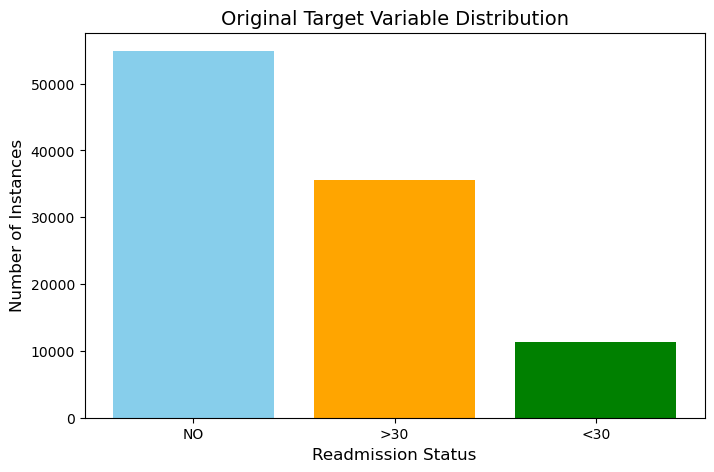

In [14]:
# Visualize original class distribution for the target variable before class imbalance handling
original_counts = diabetic_data['readmitted'].value_counts()
classes = original_counts.index
counts = original_counts.values

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['skyblue', 'orange', 'green'])
plt.title('Original Target Variable Distribution', fontsize=14)
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.xticks(rotation=0)
plt.show()

In [15]:
"""
The mapping done below essentialy converts the modeling task into a binary class
classification task where we want to predict whether an individual is readmitted within 
30 days or not.
"""
target_mapping = {
    "NO": 0,
    ">30": 0,
    "<30": 1
}

diabetic_data["readmitted"] = diabetic_data["readmitted"].map(target_mapping)

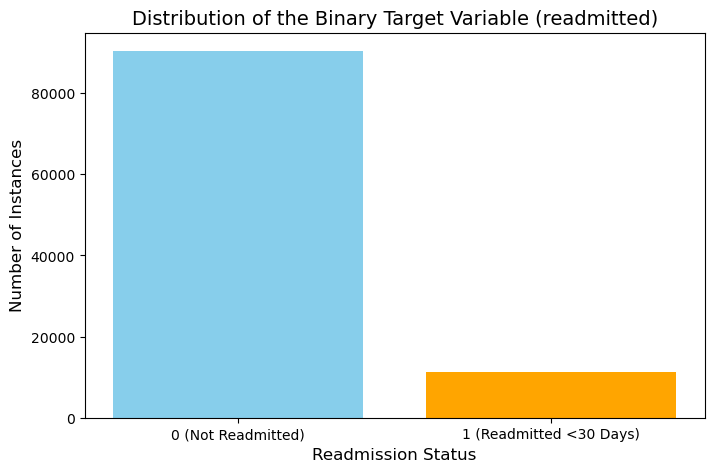

In [16]:
# Visualize binary target variable distribution after transformation
binary_counts = diabetic_data['readmitted'].value_counts()
classes = binary_counts.index
counts = binary_counts.values

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['skyblue', 'orange'])
plt.title('Distribution of the Binary Target Variable (readmitted)', fontsize=14)
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0 (Not Readmitted)', '1 (Readmitted <30 Days)'], fontsize=10)
plt.show()

In [17]:
# Check the number of values in each target variable class
diabetic_data.readmitted.value_counts()

# We can see there's a significant class balance, which must be addressed

readmitted
0    90409
1    11357
Name: count, dtype: int64

In [18]:
"""
SMOTE-NC is the technique to be used for oversampling here. This was chosen because the
dataset contains a mix of numerical features and categorical features. SMOTE-NC handles these
mixed types appropriately without disrupting categorical relationships.

SMOTE, on the other hand, will increase the cardinality of the categorical features significantly causing the
model training to take a longer time without yielding the best results. Hence, SMOTE-NC was 
preferred.
"""

# Define features and target
X = diabetic_data.drop("readmitted", axis=1)  # Features
y = diabetic_data["readmitted"]              # Target

# Pick out the categorical features
categorical_features = diabetic_data.select_dtypes(include=["object", "category"]).columns.tolist()

# Get indices of categorical features
categorical_feature_indices = [X.columns.get_loc(col) for col in categorical_features]

# Apply SMOTE-NC technique
smote_nc = SMOTENC(categorical_features=categorical_feature_indices, random_state=0)
X_resampled, y_resampled = smote_nc.fit_resample(X, y)

# Combine resampled features and target into a DataFrame
diabetic_data_resampled = pd.concat(
    [pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name="readmitted")],
    axis=1
)

# Replace original dataset
diabetic_data = diabetic_data_resampled

In [19]:
# Check
diabetic_data.readmitted.value_counts()

# Now, classes 0 and 1 are balanced

readmitted
0    90409
1    90409
Name: count, dtype: int64

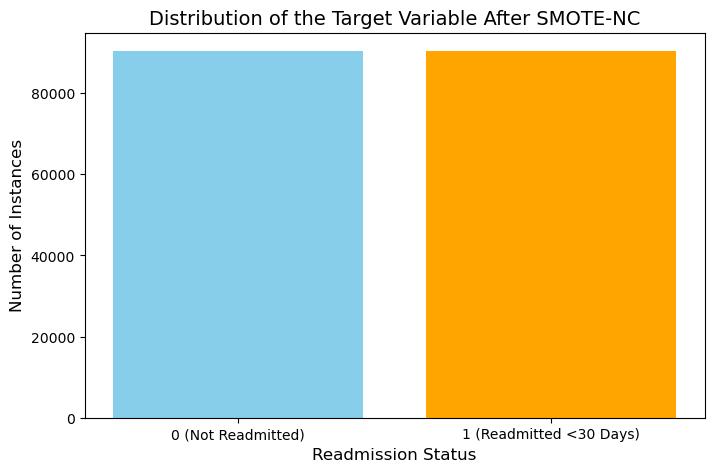

In [20]:
# Assume `smote_nc_data` contains the dataset after SMOTE-NC oversampling
smote_nc_counts = diabetic_data['readmitted'].value_counts()
classes = smote_nc_counts.index
counts = smote_nc_counts.values

# Plot the class distribution after SMOTE-NC
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['skyblue', 'orange'])
plt.title('Distribution of the Target Variable After SMOTE-NC', fontsize=14)
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0 (Not Readmitted)', '1 (Readmitted <30 Days)'], fontsize=10)
plt.show()

## Handle Column Cardinality

In [21]:
# Function to calculate and return the cardinality of each column in the DataFrame
def check_column_cardinality(df):
  count_dict = dict()
  for col in df.columns:
    count_dict[col] = len(df[col].unique())
  return count_dict

In [22]:
# Filter for numerical and categorical columns
numerical_columns = [
    x for x in diabetic_data.columns if diabetic_data[x].dtype != "object"
    ]
categorical_columns = [
    x for x in diabetic_data.columns if diabetic_data[x].dtype == "object"
]

In [23]:
"""
High cardinality columns are not good for modelling as they significantly increase
the number of columns when encoded.
"""
check_column_cardinality(diabetic_data)

{'encounter_id': 180772,
 'patient_nbr': 148712,
 'race': 5,
 'gender': 3,
 'age': 10,
 'admission_type_id': 8,
 'discharge_disposition_id': 28,
 'admission_source_id': 23,
 'time_in_hospital': 14,
 'num_lab_procedures': 122,
 'num_procedures': 7,
 'num_medications': 76,
 'number_outpatient': 41,
 'number_emergency': 39,
 'number_inpatient': 22,
 'diag_1': 716,
 'diag_2': 748,
 'diag_3': 789,
 'number_diagnoses': 16,
 'metformin': 4,
 'repaglinide': 4,
 'nateglinide': 4,
 'chlorpropamide': 4,
 'glimepiride': 4,
 'acetohexamide': 2,
 'glipizide': 4,
 'glyburide': 4,
 'tolbutamide': 2,
 'pioglitazone': 4,
 'rosiglitazone': 4,
 'acarbose': 4,
 'miglitol': 4,
 'troglitazone': 2,
 'tolazamide': 3,
 'examide': 1,
 'citoglipton': 1,
 'insulin': 4,
 'glyburide-metformin': 4,
 'glipizide-metformin': 2,
 'glimepiride-pioglitazone': 2,
 'metformin-rosiglitazone': 2,
 'metformin-pioglitazone': 2,
 'change': 2,
 'diabetesMed': 2,
 'readmitted': 2}

In [24]:
# These are high cardinality and are id columns, so they can be dropped
diabetic_data.drop(
    [
        "encounter_id",
        "patient_nbr",
    ],
    axis=1,
    inplace=True
)

## Feature Selection

In [25]:
# Function to carry out ordinal encoding on categorical columns in the dataframe
def ordinal_encode(df, encoder):
  categoricals = [
    x for x in df.columns if df[x].dtype == "object"
  ]
  encoded = encoder.fit_transform(df[categoricals])
  df[categoricals] = encoded
  return df

In [26]:
ordinal_encoder = OrdinalEncoder()

# Apply ordinal encoding to the categorical columns in the dataframe
df_ord = ordinal_encode(diabetic_data, ordinal_encoder)

# View the first five rows of the encoded dataframe
df_ord.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2.0,0.0,0,6,25,1,1,41,0,1,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,2.0,0.0,1,1,1,7,3,59,0,18,...,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,0.0,0.0,2,1,1,7,2,11,5,13,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0
3,2.0,1.0,3,1,1,7,2,44,1,16,...,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,2.0,1.0,4,1,1,7,1,51,0,8,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0


In [27]:
# Redefine X following the previously-dropped columns
X = diabetic_data.drop("readmitted", axis=1)
y = diabetic_data["readmitted"]

# Calculate mutual information scores for feature selection
mi_scores = mutual_info_classif(X, y, random_state=0)
mi_scores = pd.Series(mi_scores, index=X.columns)

# Select the top 10 features based on the MI scores
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores[:10]

admission_source_id         0.087343
discharge_disposition_id    0.085384
diabetesMed                 0.041091
metformin                   0.038939
pioglitazone                0.033804
rosiglitazone               0.033142
admission_type_id           0.031890
glimepiride                 0.029438
number_diagnoses            0.028954
glipizide                   0.028813
dtype: float64

<Axes: >

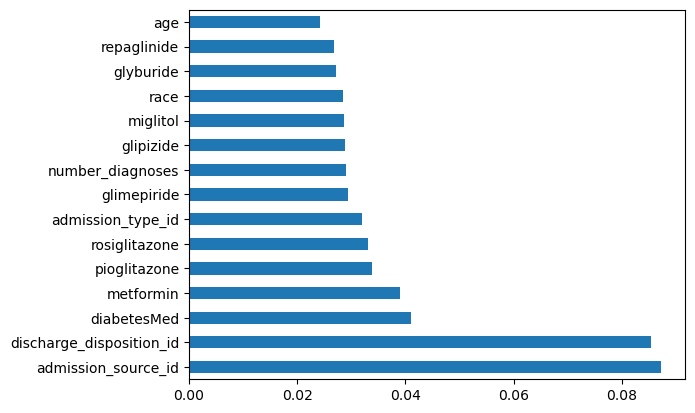

In [28]:
mi_scores[:15].plot(kind="barh")

In [29]:
"""
Looking at the plots, there seems to be a dropoff in MI scores after the 5th
feature. The first 5 highest scoring features are selected.
"""
selected_features = mi_scores.index[:5]
selected_features

Index(['admission_source_id', 'discharge_disposition_id', 'diabetesMed',
       'metformin', 'pioglitazone'],
      dtype='object')

## Model Building

In [30]:
# Function to apply one-hot encoding to categorical variables
def one_hot_encode(df, encoder):
  encoded = encoder.fit_transform(df).toarray()
    
  # Get the names of the new one-hot encoded columns
  column_headers = list(encoder.get_feature_names_out())

  # Create a dataframe from the encoded data with proper column names
  temp_df = pd.DataFrame(encoded, columns=column_headers)
    
  return temp_df # Return the encoded dataframe

In [31]:
oh_encoder = OneHotEncoder(handle_unknown="ignore")
X = one_hot_encode(diabetic_data[selected_features], oh_encoder)
y = diabetic_data["readmitted"]

# Split the dataset into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [32]:
# Define a function to train a model and evaluate its performance
def train_model(
    model, x_train, y_train, x_val, y_val
):
  model.fit(x_train, y_train)
  y_pred = model.predict(X_val)
    
  # Calculate and display the confusion matrix
  cm = confusion_matrix(y_val, y_pred)

  print("Accuracy:", accuracy_score(y_val, y_pred))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()
  print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.7287357593186594
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.76     18007
           1       0.81      0.60      0.69     18157

    accuracy                           0.73     36164
   macro avg       0.74      0.73      0.72     36164
weighted avg       0.74      0.73      0.72     36164



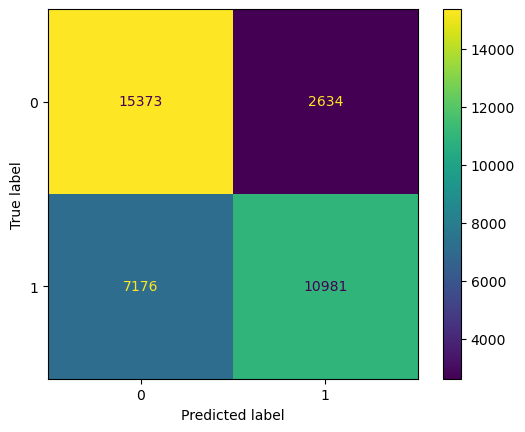

In [33]:
"""
Define a logistic regression model using balanced class weights and a maximum iteration of 1,000
"""
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.7287357593186594
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.76     18007
           1       0.81      0.60      0.69     18157

    accuracy                           0.73     36164
   macro avg       0.74      0.73      0.72     36164
weighted avg       0.74      0.73      0.72     36164



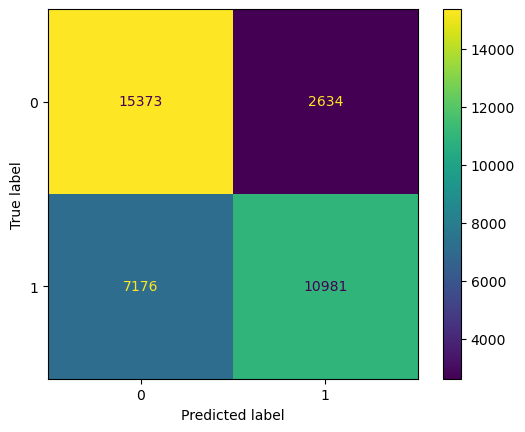

In [34]:
# Initialise a random forest model and check its performance
rf_model = RandomForestClassifier(random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.7287357593186594
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.76     18007
           1       0.81      0.60      0.69     18157

    accuracy                           0.73     36164
   macro avg       0.74      0.73      0.72     36164
weighted avg       0.74      0.73      0.72     36164



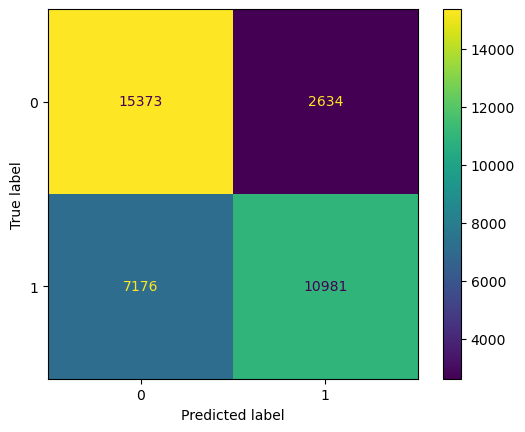

In [35]:
# Class weights are added to try to improve the model's performance and make it more balanced
rf_model = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.7371142572724256
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.90      0.77     18007
           1       0.86      0.57      0.69     18157

    accuracy                           0.74     36164
   macro avg       0.77      0.74      0.73     36164
weighted avg       0.77      0.74      0.73     36164



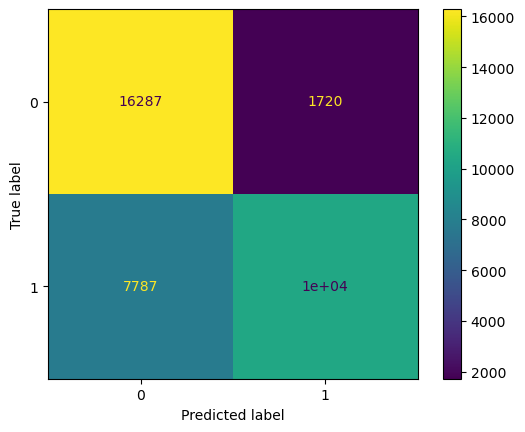

In [36]:
# Define a XGBoost model and check its evaluation metrics
xgb_model = XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')

train_model(
    xgb_model, X_train, y_train, X_val, y_val
)

Accuracy: 0.7353721933414445
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.86      0.76     18007
           1       0.81      0.62      0.70     18157

    accuracy                           0.74     36164
   macro avg       0.75      0.74      0.73     36164
weighted avg       0.75      0.74      0.73     36164



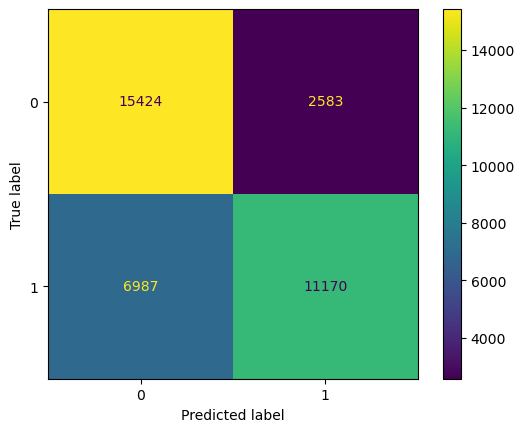

In [37]:
# Stacking classifier combining xgboost and random forest as base models
# Logistic regression is the final estimator
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model)
    ],
    final_estimator=LogisticRegression(random_state=0)
)

train_model(
    stacking_model, X_train, y_train, X_val, y_val
)

In [38]:
"""
The result can be better, so we'll select new features.

Using MI scores only to select features may not be the best because it focuses on individual relationship
between one variable and the target variable, so it may not account for interaction with other features.

So, it may be helpful to combine MI scores with model-derived feature importance as well as domain
knowledge.

This is how these new features have come about - a good mixture of categorical and numerical features as well.
"""

new_features = [
    "admission_source_id", "discharge_disposition_id", 
    "diabetesMed", "metformin", 
    "number_inpatient", "number_diagnoses", 
    "diag_1", "diag_2", "diag_3"
]

In [39]:
def one_hot_encode(df, encoder):
  encoded = encoder.fit_transform(df).toarray()
  column_headers = list(encoder.get_feature_names_out())

  temp_df = pd.DataFrame(encoded, columns=column_headers)
  return temp_df

In [40]:
oh_encoder = OneHotEncoder(handle_unknown="ignore")
X = one_hot_encode(diabetic_data[new_features], oh_encoder)
y = diabetic_data["readmitted"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

Accuracy: 0.765595619953545
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.81      0.78     18082
           1       0.79      0.72      0.75     18082

    accuracy                           0.77     36164
   macro avg       0.77      0.77      0.77     36164
weighted avg       0.77      0.77      0.77     36164



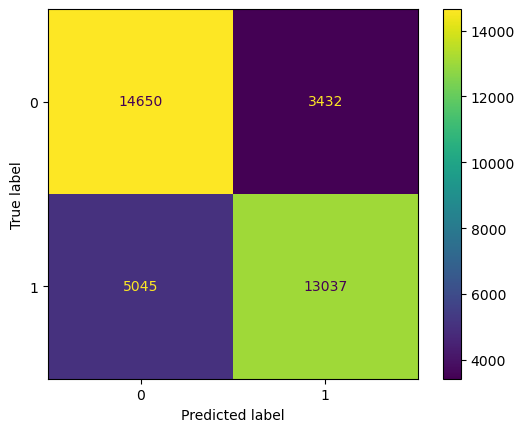

In [41]:
# Initialise a logistic regression again
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.765595619953545
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.81      0.78     18082
           1       0.79      0.72      0.75     18082

    accuracy                           0.77     36164
   macro avg       0.77      0.77      0.77     36164
weighted avg       0.77      0.77      0.77     36164



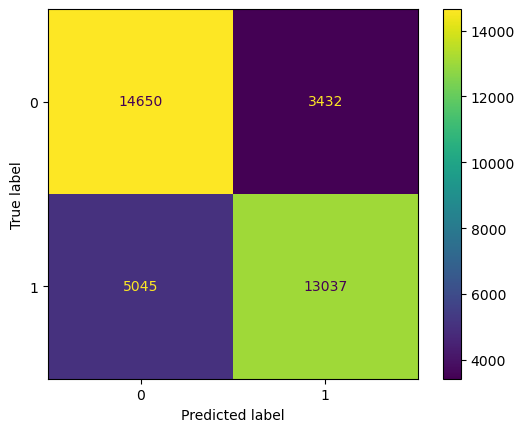

In [42]:
# Train a random forest model again
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.7832098219223538
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80     18082
           1       0.83      0.71      0.77     18082

    accuracy                           0.78     36164
   macro avg       0.79      0.78      0.78     36164
weighted avg       0.79      0.78      0.78     36164



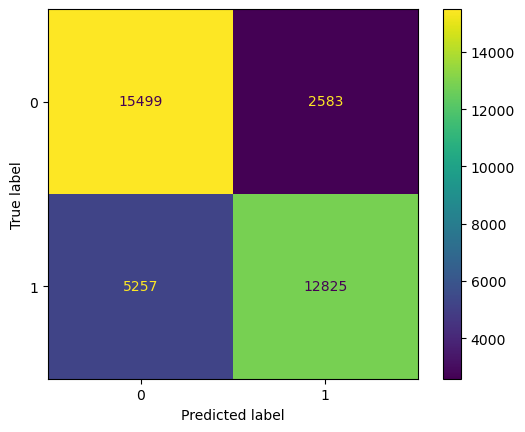

In [43]:
# Train the XGBoost model again
xgb_model = XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')

train_model(
    xgb_model, X_train, y_train, X_val, y_val
)

# This gives the best performance of all the models and settings

In [44]:
"""
XGBoost provides the most balanced evaluation metrics across classes 0 and 1.
Also, the gradient boosting algorithm recorded the highest accuracy with a
score of 78%.

Hence, we'll save it and use it as our model for implementation and deployment.
"""

# Save the model to a file
joblib.dump(xgb_model, 'xgboost_model.pkl')
print("Model saved successfully!")

"\nXGBoost provides the most balanced evaluation metrics across classes 0 and 1.\nAlso, the gradient boosting algorithm recorded the highest accuracy with a\nscore of 78%.\n\nHence, we'll save it and use it as our model for implementation and deployment.\n"

<Axes: title={'center': 'Top 20 Features by Coefficient'}>

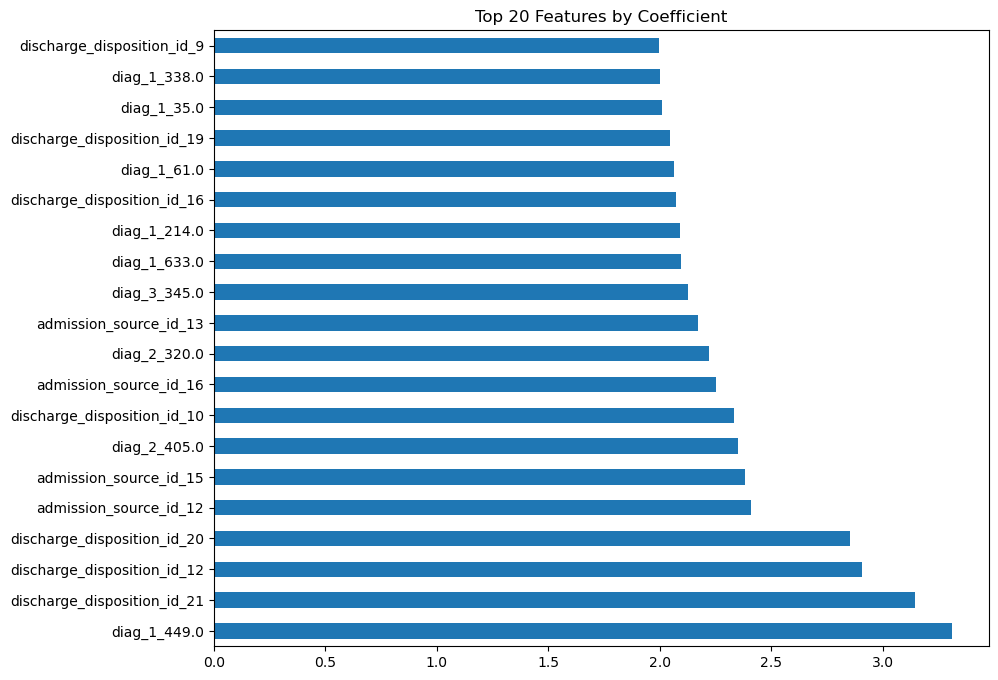

In [45]:
# Extract feature importance from the logistic regression model
importance = pd.Series(model.coef_[0], index=X_train.columns)

# Plot top 20 features impacting the target variable
top_features = importance.sort_values(ascending=False).head(20)
top_features.plot(kind="barh", figsize=(10, 8), title="Top 20 Features by Coefficient")

In [46]:
"""
The stacking classifier takes too long to train. Too computationally expensive and
time-consuming, so I'll rather not run the model.
""" 

#stacking_model = StackingClassifier(
#    estimators=[
#        ('xgb', xgb_model),
#        ('rf', rf_model)
#    ],
#    final_estimator=model
#)

#train_model(
#    stacking_model, X_train, y_train, X_val, y_val
#)

"\nThe stacking classifier takes too long to train. Too computationally expensive and\ntime-consuming, so I'll rather not run the model.\n"

In [47]:
"""
The hyperparatuning process takes too long and is too computationally expensive
"""

# Define the logistic regression model
#model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)

# Define the randomized search
#random_search = RandomizedSearchCV(
#    estimator=model,
#    param_distributions=param_grid,
#    n_iter=50,          # Try 50 random combinations
 #   cv=3,               # 3-fold cross-validation
 #   verbose=2,          # Show progress
  #  random_state=0,
 #   n_jobs=-1           # Use all available cores
)

# Run the search
#random_search.fit(X_train, y_train)

# Best parameters and score
#print("Best Parameters:", random_search.best_params_)
#print("Best Score:", random_search.best_score_)

SyntaxError: unmatched ')' (3984450789.py, line 17)

## Explainable AI (SHAP & LIME)

In [48]:
"""
Of all the tried-and-tested algorithms,XGBoost provided the most balanced
evaluation metrics across classes 0 and 1. Also, the gradient boosting 
algorithm recorded the highest accuracy with a score of 78%.

Hence, I'll choose it as our model for implementation and deployment.
"""
# Load the saved xgboost model into memory
xgb_model = joblib.load('xgboost_model.pkl')
print('Model loaded successfully!')

Model loaded successfully!


100%|===================| 144426/144654 [05:44<00:00]        

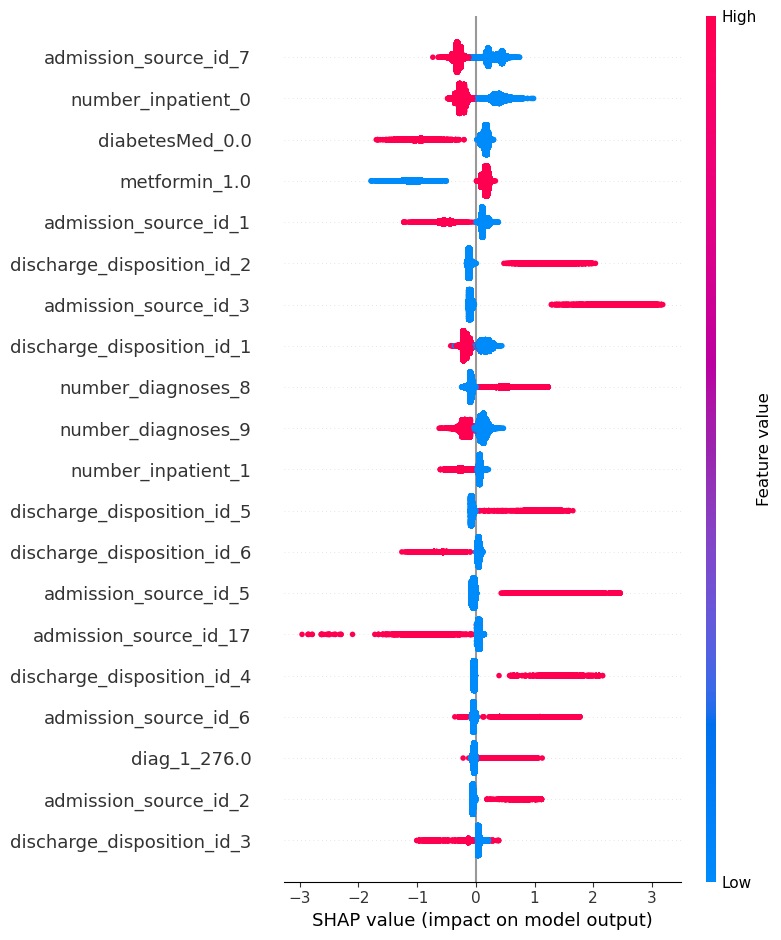

In [49]:
# Define the SHAP explainer for the loaded xgboost model
explainer = shap.Explainer(xgb_model, X_train)

# Find out the SHAP values for the training dataset
shap_values = explainer(X_train)

# Show a summary plot to check out for feature importance
shap.summary_plot(shap_values, X_train)

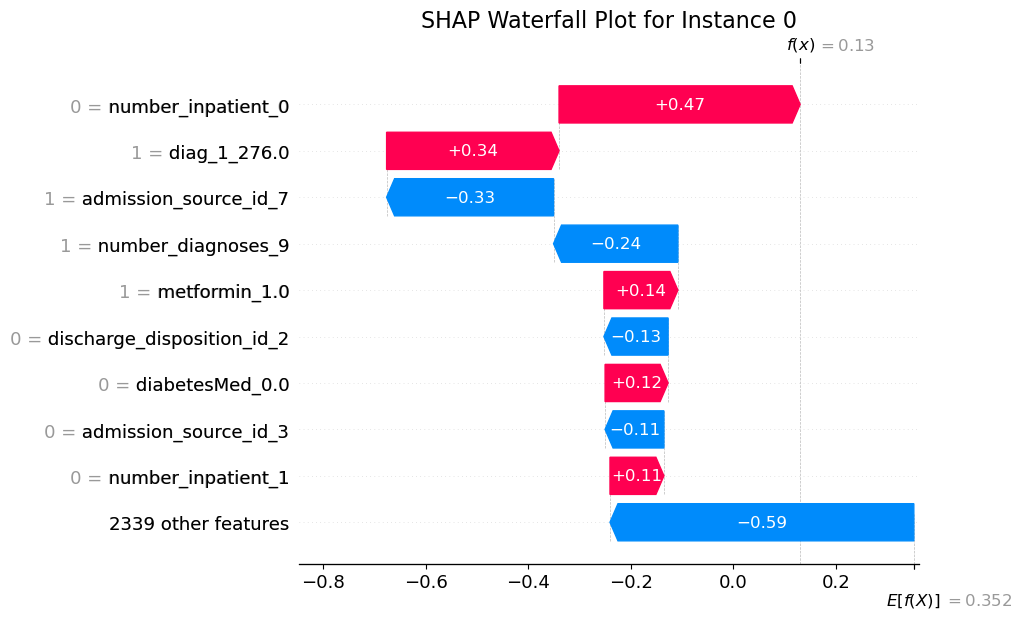

In [50]:
# Select a single instance from the validation dataset for the explanation
instance_index = 0  # Change this to select a different instance
single_instance = X_val.iloc[[instance_index]]  # Note the double brackets to keep it as a DataFrame

# Create a SHAP explainer
explainer = shap.Explainer(xgb_model, X_train)

# Calculate SHAP values for the single instance
shap_values_instance = explainer(single_instance)

# Generate a SHAP waterfall plot
plt.title(f"SHAP Waterfall Plot for Instance {instance_index}", fontsize=16)
shap.plots.waterfall(shap_values_instance[0])  # Plot for the first (and only) instance

In [51]:
import json

# JSON data
feature_mappings = {
    "admission_source_id": {
        "1": "Physician Referral",
        "2": "Clinic Referral",
        "3": "HMO Referral",
        "4": "Transfer from another hospital",
        "5": "Transfer from a Skilled Nursing Facility (SNF)",
        "6": "Transfer from another health care facility",
        "7": "Emergency Room",
        "8": "Court/Law Enforcement",
        "9": "Not Available",
        "10": "Transfer from Critical Access Hospital",
        "11": "Normal Delivery",
        "12": "Premature Delivery",
        "13": "Sick Baby",
        "14": "Extramural Birth",
        "15": "Transfer from another Home Health Agency",
        "16": "Readmission to Same Home Health Agency",
        "17": "Unknown",
        "18": "Info Not Available",
        "19": "Transfer from Hospital Inpatient in Same Facility Resulting in a Separate Claim",
        "20": "Transfer from Ambulatory Surgery Center",
        "21": "Transfer from Hospice",
        "22": "Transfer from Another Rehab Facility",
        "23": "Born Inside this Hospital",
        "24": "Born Outside this Hospital",
        "25": "Transfer from Ambulatory Surgery Center",
        "26": "Transfer from Hospice"
    },
    "discharge_disposition_id": {
        "1": "Discharged to Home",
        "2": "Discharged/Transferred to Another Short-Term Hospital",
        "3": "Discharged/Transferred to SNF",
        "4": "Discharged/Transferred to ICF",
        "5": "Discharged/Transferred to Another Inpatient Care Institution",
        "6": "Discharged to Home with Home Health Service",
        "7": "Left Against Medical Advice (AMA)",
        "8": "Discharged/Transferred to Home Under Home IV Provider",
        "9": "Discharged/Transferred to a Federal Health Care Facility",
        "10": "Discharged/Transferred to Another Health Care Facility",
        "11": "Expired",
        "12": "Still a Patient/Expected to Return for Outpatient Services",
        "13": "Hospice / Home",
        "14": "Hospice / Medical Facility",
        "15": "Discharged/Transferred Within Institution to Medicare Swing Bed",
        "16": "Discharged to Outpatient Services in Another Institution",
        "17": "Discharged to Outpatient Services in the Same Institution",
        "18": "Null",
        "19": "Expired at Home",
        "20": "Expired in a Medical Facility",
        "21": "Expired, Place Unknown",
        "22": "Transferred to Another Rehab Facility",
        "23": "Transferred to a Long-Term Care Hospital",
        "24": "Transferred to a Medicaid-Certified Nursing Facility (Non-Medicare)",
        "25": "Not Mapped",
        "26": "Unknown/Invalid",
        "27": "Transferred to Another Type of Institution Not Defined Elsewhere",
        "28": "Transferred to a Psychiatric Hospital/Unit",
        "29": "Transferred to Critical Access Hospital"
    },
    "diabetesMed": {
        "0.0": "Not on diabetes medication",
        "1.0": "On diabetes medication"
    },
    "metformin": {
        "0.0": "Not on Metformin",
        "1.0": "Metformin (Steady Dose)",
        "2.0": "Metformin (Dose Increased)",
        "3.0": "Metformin (Dose Decreased)"
    },
    "number_inpatient": {
        "0": "No prior inpatient visits",
        "1": "1 prior inpatient visit",
        "2": "2 prior inpatient visits",
        "3": "3 prior inpatient visits",
        "4": "4 prior inpatient visits",
        "5": "5 prior inpatient visits",
        "6": "6 prior inpatient visits",
        "7": "7 prior inpatient visits",
        "8": "8 prior inpatient visits",
        "9": "9 prior inpatient visits",
        "10": "10 prior inpatient visits",
        "11": "11 prior inpatient visits",
        "12": "12 prior inpatient visits",
        "13": "13 prior inpatient visits",
        "14": "14 prior inpatient visits",
        "15": "15 prior inpatient visits",
        "16": "16 prior inpatient visits",
        "17": "17 prior inpatient visits",
        "18": "18 prior inpatient visits",
        "19": "19 prior inpatient visits",
        "21": "21 prior inpatient visits"
    },
    "number_diagnoses": {
        "1": "1 diagnosis recorded",
        "2": "2 diagnoses recorded",
        "3": "3 diagnoses recorded",
        "4": "4 diagnoses recorded",
        "5": "5 diagnoses recorded",
        "6": "6 diagnoses recorded",
        "7": "7 diagnoses recorded",
        "8": "8 diagnoses recorded",
        "9": "9 diagnoses recorded",
        "10": "10 diagnoses recorded",
        "11": "11 diagnoses recorded",
        "12": "12 diagnoses recorded",
        "13": "13 diagnoses recorded",
        "14": "14 diagnoses recorded",
        "15": "15 diagnoses recorded",
        "16": "16 diagnoses recorded"
    },
    "diag_1": {
        "390-459, 785": "Diseases of the circulatory system",
        "460-519, 786": "Diseases of the respiratory system",
        "520-579, 787": "Diseases of the digestive system",
        "250.xx": "Diabetes mellitus",
        "800-999": "Injury and poisoning",
        "710-739": "Diseases of the musculoskeletal system and connective tissue",
        "580-629, 788": "Diseases of the genitourinary system",
        "140-239": "Neoplasms",
        "780, 781, 784, 790-799": "Other symptoms, signs, and ill-defined conditions",
        "240-279": "Endocrine, nutritional, and metabolic diseases"
    },
    "diag_2": {
        "390-459, 785": "Diseases of the circulatory system",
        "460-519, 786": "Diseases of the respiratory system",
        "520-579, 787": "Diseases of the digestive system",
        "250.xx": "Diabetes mellitus",
        "800-999": "Injury and poisoning",
        "710-739": "Diseases of the musculoskeletal system and connective tissue",
        "580-629, 788": "Diseases of the genitourinary system",
        "140-239": "Neoplasms",
        "780, 781, 784, 790-799": "Other symptoms, signs, and ill-defined conditions",
        "240-279": "Endocrine, nutritional, and metabolic diseases"
    },
    "diag_3": {
        "390-459, 785": "Diseases of the circulatory system",
        "460-519, 786": "Diseases of the respiratory system",
        "520-579, 787": "Diseases of the digestive system",
        "250.xx": "Diabetes mellitus",
        "800-999": "Injury and poisoning",
        "710-739": "Diseases of the musculoskeletal system and connective tissue",
        "580-629, 788": "Diseases of the genitourinary system",
        "140-239": "Neoplasms",
        "780, 781, 784, 790-799": "Other symptoms, signs, and ill-defined conditions",
        "240-279": "Endocrine, nutritional, and metabolic diseases"
    }
}

# Save as JSON file
with open('feature_mappings.json', 'w') as f:
    json.dump(feature_mappings, f, indent=4)
print('JSON file saved!')

JSON file saved!
